# Formula 1 World Championship Analysis
## Exploratory Data Analysis
* **Goal:** Analyze Formula 1 race results, drivers, constructors and circuits to identify patterns in driver performance, race outcomes and historical trends.

In [2]:
# Import libraries for EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Create function for safe loading of csv files
def load_csv(filepath):
    try:
        df = pd.read_csv(filepath)
        print(f'{filepath} successfully loaded')
        return df
    except FileNotFoundError:
        print(f'{filepath} not found')
    except Exception as e:
        print(f'Error loading {filepath}: {e}')

In [4]:
# Load CSV Files

circuits = load_csv('../data/circuits.csv')
constructor_results = load_csv('../data/constructor_results.csv')
constructor_standings = load_csv('../data/constructor_standings.csv')
constructors = load_csv('../data/constructors.csv')
driver_standings = load_csv('../data/driver_standings.csv')
drivers = load_csv('../data/drivers.csv')
lap_times = load_csv('../data/lap_times.csv')
pit_stops = load_csv('../data/pit_stops.csv')
qualifying = load_csv('../data/qualifying.csv')
races = load_csv('../data/races.csv')
results = load_csv('../data/results.csv')
seasons = load_csv('../data/seasons.csv')
sprint_results = load_csv('../data/sprint_results.csv')
status = load_csv('../data/status.csv')

../data/circuits.csv successfully loaded
../data/constructor_results.csv successfully loaded
../data/constructor_standings.csv successfully loaded
../data/constructors.csv successfully loaded
../data/driver_standings.csv successfully loaded
../data/drivers.csv successfully loaded
../data/lap_times.csv successfully loaded
../data/pit_stops.csv successfully loaded
../data/qualifying.csv successfully loaded
../data/races.csv successfully loaded
../data/results.csv successfully loaded
../data/seasons.csv successfully loaded
../data/sprint_results.csv successfully loaded
../data/status.csv successfully loaded


In [5]:
# Create function for inspection of dataset
def dataset_inspection(df):
    print('Dataset Shape:')
    print(f'Rows: {df.shape[0]} -- Columns: {df.shape[1]}')

    print('\nDataset Information:')
    df.info()

    print('\nMissing Values:')
    display(df.isna().sum())

    print('\nDatset Head:')
    display(df.head())
    
    return df

In [6]:
dataset_inspection(drivers)

Dataset Shape:
Rows: 861 -- Columns: 9

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 861 entries, 0 to 860
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   driverId     861 non-null    int64 
 1   driverRef    861 non-null    object
 2   number       861 non-null    object
 3   code         861 non-null    object
 4   forename     861 non-null    object
 5   surname      861 non-null    object
 6   dob          861 non-null    object
 7   nationality  861 non-null    object
 8   url          861 non-null    object
dtypes: int64(1), object(8)
memory usage: 60.7+ KB

Missing Values:


driverId       0
driverRef      0
number         0
code           0
forename       0
surname        0
dob            0
nationality    0
url            0
dtype: int64


Datset Head:


,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,\N,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,alonso,14,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,kovalainen,\N,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen


,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,\N,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,alonso,14,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,kovalainen,\N,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen
...,...,...,...,...,...,...,...,...,...
856,858,sargeant,2,SAR,Logan,Sargeant,2000-12-31,American,http://en.wikipedia.org/wiki/Logan_Sargeant
857,859,lawson,30,LAW,Liam,Lawson,2002-02-11,New Zealander,http://en.wikipedia.org/wiki/Liam_Lawson
858,860,bearman,38,BEA,Oliver,Bearman,2005-05-08,British,http://en.wikipedia.org/wiki/Oliver_Bearman
859,861,colapinto,43,COL,Franco,Colapinto,2003-05-27,Argentinian,http://en.wikipedia.org/wiki/Franco_Colapinto


In [7]:
dataset_inspection(results)

Dataset Shape:
Rows: 26759 -- Columns: 18

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26759 entries, 0 to 26758
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resultId         26759 non-null  int64  
 1   raceId           26759 non-null  int64  
 2   driverId         26759 non-null  int64  
 3   constructorId    26759 non-null  int64  
 4   number           26759 non-null  object 
 5   grid             26759 non-null  int64  
 6   position         26759 non-null  object 
 7   positionText     26759 non-null  object 
 8   positionOrder    26759 non-null  int64  
 9   points           26759 non-null  float64
 10  laps             26759 non-null  int64  
 11  time             26759 non-null  object 
 12  milliseconds     26759 non-null  object 
 13  fastestLap       26759 non-null  object 
 14  rank             26759 non-null  object 
 15  fastestLapTime   26759 non-null  object 

resultId           0
raceId             0
driverId           0
constructorId      0
number             0
grid               0
position           0
positionText       0
positionOrder      0
points             0
laps               0
time               0
milliseconds       0
fastestLap         0
rank               0
fastestLapTime     0
fastestLapSpeed    0
statusId           0
dtype: int64


Datset Head:


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26754,26760,1144,825,210,20,14,16,16,16,0.0,57,\N,\N,57,1,1:25.637,222.002,11
26755,26761,1144,859,215,30,12,17,17,17,0.0,55,\N,\N,52,12,1:28.751,214.212,5
26756,26762,1144,822,15,77,9,\N,R,18,0.0,30,\N,\N,14,19,1:29.482,212.462,130
26757,26763,1144,861,3,43,20,\N,R,19,0.0,26,\N,\N,5,17,1:29.411,212.631,5


In [8]:
# Merge both CSV 'drivers' and 'result'
drivers_results_df = results.merge(drivers, on='driverId')

# Display merged DataFrame
display(drivers_results_df.head())

,resultId,raceId,driverId,constructorId,number_x,grid,position,positionText,positionOrder,points,...,fastestLapSpeed,statusId,driverRef,number_y,code,forename,surname,dob,nationality,url
0,1,18,1,1,22,1,1,1,1,10.0,...,218.300,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,18,2,2,3,5,2,2,2,8.0,...,217.586,1,heidfeld,\N,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,18,3,3,7,7,3,3,3,6.0,...,216.719,1,rosberg,6,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,18,4,4,5,11,4,4,4,5.0,...,215.464,1,alonso,14,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,18,5,1,23,3,5,5,5,4.0,...,218.385,1,kovalainen,\N,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen


In [9]:
# Identify drivers with the most race wins
winners_count = drivers_results_df[drivers_results_df['positionOrder'] == 1]
print(winners_count.groupby(['surname','forename']).size().sort_values(ascending=False).head(20))

surname     forename 
Hamilton    Lewis        105
Schumacher  Michael       91
Verstappen  Max           63
Vettel      Sebastian     53
Prost       Alain         51
Senna       Ayrton        41
Alonso      Fernando      32
Mansell     Nigel         31
Stewart     Jackie        27
Clark       Jim           25
Lauda       Niki          25
Fangio      Juan          24
Rosberg     Nico          23
Piquet      Nelson        23
Hill        Damon         22
Räikkönen   Kimi          21
Häkkinen    Mika          20
Moss        Stirling      16
Button      Jenson        15
Fittipaldi  Emerson       14
dtype: int64


In [10]:
# Calculate the total World Championship points by driver
print(drivers_results_df.groupby(['surname', 'forename'])['points'].sum().sort_values(ascending=False).head(20))

surname      forename 
Hamilton     Lewis        4820.5
Vettel       Sebastian    3098.0
Verstappen   Max          2912.5
Alonso       Fernando     2329.0
Räikkönen    Kimi         1873.0
Bottas       Valtteri     1788.0
Rosberg      Nico         1594.5
Pérez        Sergio       1585.0
Schumacher   Michael      1566.0
Leclerc      Charles      1363.0
Ricciardo    Daniel       1320.0
Button       Jenson       1235.0
Sainz        Carlos       1203.5
Massa        Felipe       1167.0
Webber       Mark         1047.5
Norris       Lando         950.0
Prost        Alain         798.5
Russell      George        664.0
Barrichello  Rubens        658.0
Senna        Ayrton        614.0
Name: points, dtype: float64


**Note:**

Comparing the number of race wins with the total World Championship (WM) points reveals some interesting differences. Lewis Hamilton ranks **first** in both categories. Michael Schumacher is **second** in terms of race wins, but only **ninth** when ranked by total WM points.

Hamilton has **14 more race wins** than Schumacher. This gap becomes even more noticeable when comparing their total World Championship points, where Hamilton has **[insert point difference]** more points than Schumacher.

In [11]:
# Check for winners count by nationality
nat_winners_count = drivers_results_df[drivers_results_df['positionOrder'] == 1]
print(nat_winners_count.groupby('nationality').size().sort_values(ascending=False).head(20))

nationality
British          317
German           179
Brazilian        101
French            81
Dutch             63
Finnish           57
Australian        45
Italian           43
Austrian          41
Argentine         38
Spanish           36
American          33
Canadian          17
New Zealander     12
Swedish           12
Belgian           11
South African     10
Mexican            8
Monegasque         8
Colombian          7
dtype: int64


**Note:**

The analysis shows that British drivers have achieved the highest number of race wins (**317**), followed by German (**179**) and Brazilian (**101**) drivers. Most of the top-ranked nationalities are European, indicating that European countries have produced many of Formula 1's most successful drivers.

In [12]:
# Check Metrics of grid column
drivers_results_df['grid'].describe()

count    26759.000000
mean        11.134796
std          7.202860
min          0.000000
25%          5.000000
50%         11.000000
75%         17.000000
max         34.000000
Name: grid, dtype: float64

In [13]:
# Check how often does driver win in pole positions
pole_winners = drivers_results_df[(drivers_results_df['grid'] == 1) & (drivers_results_df['positionOrder'] == 1)]
print(len(pole_winners))

481


In [14]:
# Check for winning rate
pole_starts = drivers_results_df[drivers_results_df['grid'] == 1]
pole_win_rate = (pole_starts['positionOrder'] == 1).mean()
print(f'{pole_win_rate*100:.2f}%')

42.34%


**Note:**

The analysis shows that starting a race from pole position provides a clear advantage, but does not guarantee a race win. Out of all races in which a driver started from pole position, **481 races were won by the pole sitter**, resulting in a **win rate of 42.34%**.

This means that in more than half of the cases (**57.66%**), the driver starting from pole position did not win the race. Therefore, while pole position appears to provide an advantage, other factors also influence the final race result.

In [15]:
# Create new column to check how much positions are gained
drivers_results_df['positions_gained'] = (drivers_results_df['grid'] - drivers_results_df['positionOrder'])

drivers_results_df['positions_gained'].describe()

count    26759.000000
mean        -1.659255
std          9.613308
min        -39.000000
25%         -5.000000
50%          0.000000
75%          4.000000
max         30.000000
Name: positions_gained, dtype: float64

**Note:**

The positions_gained analysis shows that drivers changed their starting position by an average of -1.66 positions during a race. The median is 0, indicating that the typical result was no change in position. The values range from a maximum loss of 39 positions to a maximum gain of 30 positions. Overall, the results show that while drivers can gain a significant number of positions during a race, position losses are also common.

In [16]:
# Cut 'position_gained' into 3 labels with pd.cut
position_change = pd.cut(drivers_results_df['positions_gained'],
                         bins=[-float('inf'), -1, 0, float('inf')],
                         labels=['Lost Position', 'No Change', 'Gained Position']
                         )
print(position_change.value_counts())

positions_gained
Gained Position    12809
Lost Position      11605
No Change           2345
Name: count, dtype: int64


**Note:**

The analysis shows that position gains occurred slightly more often than position losses. Out of **26,759 race results**, drivers gained positions in **12,809 cases**, while positions were lost in **11,605 cases**. In **2,345 cases**, drivers finished in the same position in which they started.

Overall, this indicates that gaining positions was slightly more common than losing positions during a race.

In [17]:
# Which drivers gained the most positions on average during races
driver_position_gain = (drivers_results_df.groupby(['surname', 'forename'])
                        .agg(avg_position_gained=('positions_gained', 'mean'),
                             races=('positions_gained', 'count'))
                        )

In [18]:
driver_position_gain['races'].describe()

count    861.000000
mean      31.078978
std       56.264085
min        1.000000
25%        2.000000
50%        7.000000
75%       30.000000
max      404.000000
Name: races, dtype: float64

In [19]:
# Check for drivers with minimum of 20 races
driver_position_gain = (
    driver_position_gain[
        driver_position_gain['races'] >= 20
    ]
    .sort_values('avg_position_gained', ascending=False)
)

# Check for result
print(driver_position_gain.head(20))

                         avg_position_gained  races
surname      forename                              
Mazzacane    Gastón                 7.047619     21
Gené         Marc                   5.916667     36
Bellof       Stefan                 5.545455     22
Rothengatter Huub                   5.535714     28
Lamy         Pedro                  5.343750     32
Palmer       Jonathan               4.647727     88
Nakano       Shinji                 4.484848     33
Streiff      Philippe               4.481481     54
Beuttler     Mike                   4.448276     29
Badoer       Luca                   4.344828     58
Fittipaldi   Christian              4.000000     43
Rosier       Louis                  3.666667     39
Baumgartner  Zsolt                  3.450000     20
Takagi       Toranosuke             3.437500     32
Marques      Tarso                  3.384615     26
Monteiro     Tiago                  3.243243     37
Claes        Johnny                 3.200000     25
d'Ambrosio  

In [20]:
# Check for drivers with minimum of 50 races
driver_position_gain = (
    driver_position_gain[
        driver_position_gain['races'] >= 50
    ]
    .sort_values('avg_position_gained', ascending=False)
)

# Check for result
print(driver_position_gain.head(20))

                       avg_position_gained  races
surname    forename                              
Palmer     Jonathan               4.647727     88
Streiff    Philippe               4.481481     54
Badoer     Luca                   4.344828     58
Surer      Marc                   3.056818     88
Salo       Mika                   2.522523    111
Diniz      Pedro                  2.474747     99
Comas      Érik                   2.190476     63
Pescarolo  Henri                  2.101695     59
Verstappen Jos                    2.084112    107
Ericsson   Marcus                 1.917526     97
Glock      Timo                   1.768421     95
Rodríguez  Pedro                  1.425926     54
Sato       Takuma                 1.087912     91
Latifi     Nicholas               0.819672     61
Stroll     Lance                  0.785714    168
de la Rosa Pedro                  0.785047    107
Wurz       Alexander              0.739130     69
Stommelen  Rolf                   0.655738     61


**Note:**

Among drivers with at least 50 recorded races, Jonathan Palmer achieved the highest average position gain with **4.65 positions per race**, based on 88 races. Philippe Streiff and Luca Badoer follow with average gains of **4.48** and **4.34 positions** respectively.

The minimum of 50 races was used to reduce the influence of drivers with only a small number of race results. This makes the comparison more representative, as the average position gain is based on a larger number of races.

Overall, the results show that some drivers were particularly successful at improving their starting position during races.

In [21]:
# Inspect dataset 'races' for further investigations
dataset_inspection(races)

Dataset Shape:
Rows: 1125 -- Columns: 18

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1125 entries, 0 to 1124
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   raceId       1125 non-null   int64 
 1   year         1125 non-null   int64 
 2   round        1125 non-null   int64 
 3   circuitId    1125 non-null   int64 
 4   name         1125 non-null   object
 5   date         1125 non-null   object
 6   time         1125 non-null   object
 7   url          1125 non-null   object
 8   fp1_date     1125 non-null   object
 9   fp1_time     1125 non-null   object
 10  fp2_date     1125 non-null   object
 11  fp2_time     1125 non-null   object
 12  fp3_date     1125 non-null   object
 13  fp3_time     1125 non-null   object
 14  quali_date   1125 non-null   object
 15  quali_time   1125 non-null   object
 16  sprint_date  1125 non-null   object
 17  sprint_time  1125 non-null   object
dtypes: in

raceId         0
year           0
round          0
circuitId      0
name           0
date           0
time           0
url            0
fp1_date       0
fp1_time       0
fp2_date       0
fp2_time       0
fp3_date       0
fp3_time       0
quali_date     0
quali_time     0
sprint_date    0
sprint_time    0
dtype: int64


Datset Head:


,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N


,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1120,1140,2024,20,32,Mexico City Grand Prix,2024-10-27,20:00:00,https://en.wikipedia.org/wiki/2024_Mexico_City...,2024-10-25,18:30:00,2024-10-25,22:00:00,2024-10-26,17:30:00,2024-10-26,21:00:00,\N,\N
1121,1141,2024,21,18,São Paulo Grand Prix,2024-11-03,17:00:00,https://en.wikipedia.org/wiki/2024_S%C3%A3o_Pa...,2024-11-01,14:30:00,2024-11-01,18:30:00,\N,\N,2024-11-02,18:00:00,2024-11-02,14:00:00
1122,1142,2024,22,80,Las Vegas Grand Prix,2024-11-23,06:00:00,https://en.wikipedia.org/wiki/2024_Las_Vegas_G...,2024-11-21,02:30:00,2024-11-21,06:00:00,2024-11-22,02:30:00,2024-11-22,06:00:00,\N,\N
1123,1143,2024,23,78,Qatar Grand Prix,2024-12-01,17:00:00,https://en.wikipedia.org/wiki/2024_Qatar_Grand...,2024-11-29,13:30:00,2024-11-29,17:30:00,\N,\N,2024-11-30,17:00:00,2024-11-30,13:00:00


In [22]:
# Merge driver_results_df with races df
drivers_results_races_df = drivers_results_df.merge(races, on='raceId', how='left')

In [23]:
# Check the head of the merged dataframe
drivers_results_races_df.head()

,resultId,raceId,driverId,constructorId,number_x,grid,position,positionText,positionOrder,points,...,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,18,1,1,22,1,1,1,1,10.0,...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1,2,18,2,2,3,5,2,2,2,8.0,...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
2,3,18,3,3,7,7,3,3,3,6.0,...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
3,4,18,4,4,5,11,4,4,4,5.0,...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
4,5,18,5,1,23,3,5,5,5,4.0,...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N


In [24]:
# Check shape of new merged dataframe
print(f'Rows: {drivers_results_races_df.shape[0]} -- Columns: {drivers_results_races_df.shape[1]}')

Rows: 26759 -- Columns: 44


In [25]:
# Check head information for 'raceId', 'name', 'year' and 'circuitId'
drivers_results_races_df[['raceId', 'name', 'year', 'circuitId']].head()

,raceId,name,year,circuitId
0,18,Australian Grand Prix,2008,1
1,18,Australian Grand Prix,2008,1
2,18,Australian Grand Prix,2008,1
3,18,Australian Grand Prix,2008,1
4,18,Australian Grand Prix,2008,1


In [26]:
# Check which grand prix has been won most often
race_winners = drivers_results_races_df[drivers_results_races_df['positionOrder'] == 1]
race_win_count = (race_winners.groupby('name')
                  .size()
                  .sort_values(ascending=False)
                  )
print(race_win_count.head(20))

name
British Grand Prix          76
Italian Grand Prix          75
Monaco Grand Prix           70
Belgian Grand Prix          69
German Grand Prix           64
French Grand Prix           63
Spanish Grand Prix          54
Canadian Grand Prix         53
Brazilian Grand Prix        47
United States Grand Prix    45
Hungarian Grand Prix        39
Japanese Grand Prix         38
Australian Grand Prix       38
Austrian Grand Prix         37
Dutch Grand Prix            34
San Marino Grand Prix       26
European Grand Prix         23
South African Grand Prix    23
Argentine Grand Prix        21
Bahrain Grand Prix          20
dtype: int64


**Note:**

The British Grand Prix has the highest number of recorded race wins with **76 victories**, followed by the Italian Grand Prix with **75** and the Monaco Grand Prix with **70**. These three Grand Prix events have therefore recorded the highest number of race winners in the dataset.

The results also show that several traditional European Grands Prix appear among the most frequently held events in Formula 1 history.

In [27]:
# Check for which drivers have won the most races at each grand prix
driver_race_winners = (
    race_winners.groupby(['name', 'surname', 'forename'])
    .size()
    .sort_values(ascending=False)
)

# Check for the winners
print(driver_race_winners.head(20))

name                      surname     forename 
British Grand Prix        Hamilton    Lewis        9
Hungarian Grand Prix      Hamilton    Lewis        8
French Grand Prix         Schumacher  Michael      8
Canadian Grand Prix       Schumacher  Michael      7
                          Hamilton    Lewis        7
San Marino Grand Prix     Schumacher  Michael      7
Monaco Grand Prix         Senna       Ayrton       6
Belgian Grand Prix        Schumacher  Michael      6
Chinese Grand Prix        Hamilton    Lewis        6
Spanish Grand Prix        Schumacher  Michael      6
French Grand Prix         Prost       Alain        6
European Grand Prix       Schumacher  Michael      6
Spanish Grand Prix        Hamilton    Lewis        6
Japanese Grand Prix       Schumacher  Michael      6
Brazilian Grand Prix      Prost       Alain        6
United States Grand Prix  Hamilton    Lewis        6
Belgian Grand Prix        Hamilton    Lewis        5
Italian Grand Prix        Schumacher  Michael      

**Note:**

The analysis shows that Lewis Hamilton has the most wins at the British Grand Prix, with **9 victories**, followed by 8 wins at the Hungarian Grand Prix. Michael Schumacher achieved **8 victories at the French Grand Prix** and 7 at both the Canadian and San Marino Grands Prix.

The results also show that some Grand Prix events have been particularly successful for individual drivers. For example, Ayrton Senna won the Monaco Grand Prix **6 times**, while Hamilton and Schumacher both achieved **7 victories at the Canadian Grand Prix**.

In [28]:
# Check which drivers scored the most points at each Grand Prix?
driver_race_points = (
    drivers_results_races_df.groupby(['name', 'surname', 'forename'])['points']
    .sum()
    .sort_values(ascending=False)
)

# Check for the winners
print(driver_race_points.head(20))

name                      surname     forename 
British Grand Prix        Hamilton    Lewis        312.0
Hungarian Grand Prix      Hamilton    Lewis        286.0
Abu Dhabi Grand Prix      Hamilton    Lewis        258.0
Spanish Grand Prix        Hamilton    Lewis        248.0
Bahrain Grand Prix        Hamilton    Lewis        246.0
Canadian Grand Prix       Hamilton    Lewis        228.0
Belgian Grand Prix        Hamilton    Lewis        222.5
Italian Grand Prix        Hamilton    Lewis        218.0
United States Grand Prix  Hamilton    Lewis        217.0
Chinese Grand Prix        Hamilton    Lewis        206.0
Singapore Grand Prix      Vettel      Sebastian    199.0
Japanese Grand Prix       Hamilton    Lewis        199.0
Australian Grand Prix     Hamilton    Lewis        194.0
Monaco Grand Prix         Hamilton    Lewis        193.0
Japanese Grand Prix       Vettel      Sebastian    179.0
Monaco Grand Prix         Vettel      Sebastian    179.0
Russian Grand Prix        Hamilton    Le

**Note:**

Lewis Hamilton has accumulated the most points at the British Grand Prix, with a total of **312 points** across his race results. He also has the highest point totals at several other Grand Prix events, including the Hungarian Grand Prix (**286 points**), Abu Dhabi Grand Prix (**258 points**) and Spanish Grand Prix (**248 points**).

Sebastian Vettel and Max Verstappen also appear among the highest-scoring drivers at specific Grand Prix events. Vettel has accumulated **199 points at the Singapore Grand Prix**, while Verstappen has scored **168 points at the Spanish Grand Prix**.

Compared with the previous race-win analysis, this shows that total points provide a broader view of a driver's performance at a specific Grand Prix, as the calculation includes all race results rather than only victories.

In [29]:
# Inspection of dataset circuits
dataset_inspection(circuits)

Dataset Shape:
Rows: 77 -- Columns: 9

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   circuitId   77 non-null     int64  
 1   circuitRef  77 non-null     object 
 2   name        77 non-null     object 
 3   location    77 non-null     object 
 4   country     77 non-null     object 
 5   lat         77 non-null     float64
 6   lng         77 non-null     float64
 7   alt         77 non-null     int64  
 8   url         77 non-null     object 
dtypes: float64(2), int64(2), object(5)
memory usage: 5.5+ KB

Missing Values:


circuitId     0
circuitRef    0
name          0
location      0
country       0
lat           0
lng           0
alt           0
url           0
dtype: int64


Datset Head:


,circuitId,circuitRef,name,location,country,lat,lng,alt,url
0,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.96800,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
1,2,sepang,Sepang International Circuit,Kuala Lumpur,Malaysia,2.76083,101.73800,18,http://en.wikipedia.org/wiki/Sepang_Internatio...
2,3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.51060,7,http://en.wikipedia.org/wiki/Bahrain_Internati...
3,4,catalunya,Circuit de Barcelona-Catalunya,Montmeló,Spain,41.57000,2.26111,109,http://en.wikipedia.org/wiki/Circuit_de_Barcel...
4,5,istanbul,Istanbul Park,Istanbul,Turkey,40.95170,29.40500,130,http://en.wikipedia.org/wiki/Istanbul_Park


,circuitId,circuitRef,name,location,country,lat,lng,alt,url
0,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.96800,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
1,2,sepang,Sepang International Circuit,Kuala Lumpur,Malaysia,2.76083,101.73800,18,http://en.wikipedia.org/wiki/Sepang_Internatio...
2,3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.51060,7,http://en.wikipedia.org/wiki/Bahrain_Internati...
3,4,catalunya,Circuit de Barcelona-Catalunya,Montmeló,Spain,41.57000,2.26111,109,http://en.wikipedia.org/wiki/Circuit_de_Barcel...
4,5,istanbul,Istanbul Park,Istanbul,Turkey,40.95170,29.40500,130,http://en.wikipedia.org/wiki/Istanbul_Park
...,...,...,...,...,...,...,...,...,...
72,75,portimao,Autódromo Internacional do Algarve,Portimão,Portugal,37.22700,-8.62670,108,http://en.wikipedia.org/wiki/Algarve_Internati...
73,76,mugello,Autodromo Internazionale del Mugello,Mugello,Italy,43.99750,11.37190,255,http://en.wikipedia.org/wiki/Mugello_Circuit
74,77,jeddah,Jeddah Corniche Circuit,Jeddah,Saudi Arabia,21.63190,39.10440,15,http://en.wikipedia.org/wiki/Jeddah_Street_Cir...
75,78,losail,Losail International Circuit,Al Daayen,Qatar,25.49000,51.45420,12,http://en.wikipedia.org/wiki/Losail_Internatio...


In [30]:
# Merge previous dataframe with circuits
drivers_results_races_circuits_df = drivers_results_races_df.merge(
    circuits,
    on='circuitId',
    how='left'
    )

In [31]:
# Check the head information of the new dataframe
drivers_results_races_circuits_df.head()

,resultId,raceId,driverId,constructorId,number_x,grid,position,positionText,positionOrder,points,...,sprint_date,sprint_time,circuitRef,name_y,location,country,lat,lng,alt,url
0,1,18,1,1,22,1,1,1,1,10.0,...,\N,\N,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
1,2,18,2,2,3,5,2,2,2,8.0,...,\N,\N,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
2,3,18,3,3,7,7,3,3,3,6.0,...,\N,\N,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
3,4,18,4,4,5,11,4,4,4,5.0,...,\N,\N,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
4,5,18,5,1,23,3,5,5,5,4.0,...,\N,\N,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...


In [32]:
# Check the shape of the new merged dataframe
print(f'Rows: {drivers_results_races_circuits_df.shape[0]} -- Columns:{drivers_results_races_circuits_df.shape[1]}')

Rows: 26759 -- Columns:52


In [33]:
# Check the headinformation of 'name', 'circuitId', 'location', 'country
drivers_results_races_circuits_df[['name_y','circuitId', 'location', 'country']].head(10)

,name_y,circuitId,location,country
0,Albert Park Grand Prix Circuit,1,Melbourne,Australia
1,Albert Park Grand Prix Circuit,1,Melbourne,Australia
2,Albert Park Grand Prix Circuit,1,Melbourne,Australia
3,Albert Park Grand Prix Circuit,1,Melbourne,Australia
4,Albert Park Grand Prix Circuit,1,Melbourne,Australia
5,Albert Park Grand Prix Circuit,1,Melbourne,Australia
6,Albert Park Grand Prix Circuit,1,Melbourne,Australia
7,Albert Park Grand Prix Circuit,1,Melbourne,Australia
8,Albert Park Grand Prix Circuit,1,Melbourne,Australia
9,Albert Park Grand Prix Circuit,1,Melbourne,Australia


In [34]:
# Which countries have hosted the most formula1 races
race_country_count = (drivers_results_races_circuits_df.groupby('country')['raceId']
                      .nunique()
                      .sort_values(ascending=False)
                      )

print(race_country_count.head(20))

country
Italy           107
UK               79
Germany          79
USA              77
Monaco           70
Belgium          69
France           63
Spain            61
Canada           53
Brazil           51
Japan            40
Austria          39
Hungary          39
Australia        38
Netherlands      34
Mexico           24
South Africa     23
Bahrain          21
Argentina        20
Malaysia         19
Name: raceId, dtype: int64


**Note:**

Italy has hosted the most Formula 1 races in the dataset, with a total of **107 races**. This puts Italy clearly ahead of the UK and Germany, which have each hosted **79 races**, followed by the USA with **77 races**.

Monaco ranks fifth with **70 races**, while several other traditional Formula 1 countries such as Belgium, France, Spain and Canada are also among the countries with the highest number of hosted races.

Overall, the results show a strong historical concentration of Formula 1 races in Europe, with Italy standing out as the country that has hosted the most races.

In [35]:
# Which circuits have hosted the most formula1 races
circuit_race_count = (drivers_results_races_circuits_df
                      .groupby('name_y')['raceId']
                      .nunique()
                      .sort_values(ascending=False)
                      )

print(circuit_race_count.head(20))

name_y
Autodromo Nazionale di Monza      74
Circuit de Monaco                 70
Silverstone Circuit               59
Circuit de Spa-Francorchamps      57
Circuit Gilles Villeneuve         43
Nürburgring                       41
Autódromo José Carlos Pace        41
Hungaroring                       39
Red Bull Ring                     38
Hockenheimring                    37
Suzuka Circuit                    34
Circuit Park Zandvoort            34
Circuit de Barcelona-Catalunya    34
Autodromo Enzo e Dino Ferrari     31
Albert Park Grand Prix Circuit    27
Autódromo Hermanos Rodríguez      24
Bahrain International Circuit     21
Autódromo Juan y Oscar Gálvez     20
Kyalami                           20
Watkins Glen                      20
Name: raceId, dtype: int64


**Note:**

The **Autodromo Nazionale di Monza** has hosted the most Formula 1 races in the dataset, with **74 races**, followed by the **Circuit de Monaco** with 70 races. Silverstone Circuit and Circuit de Spa-Francorchamps rank third and fourth with **59** and **57 races** respectively.

The results show that several historic European circuits have hosted a large number of Formula 1 races. Monza stands out as the circuit with the highest number of recorded races in the dataset.

In [36]:
# Inspection of constructer dataset
dataset_inspection(constructors)

Dataset Shape:
Rows: 212 -- Columns: 5

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212 entries, 0 to 211
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   constructorId   212 non-null    int64 
 1   constructorRef  212 non-null    object
 2   name            212 non-null    object
 3   nationality     212 non-null    object
 4   url             212 non-null    object
dtypes: int64(1), object(4)
memory usage: 8.4+ KB

Missing Values:


constructorId     0
constructorRef    0
name              0
nationality       0
url               0
dtype: int64


Datset Head:


,constructorId,constructorRef,name,nationality,url
0,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
3,4,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
4,5,toro_rosso,Toro Rosso,Italian,http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso


,constructorId,constructorRef,name,nationality,url
0,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
3,4,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
4,5,toro_rosso,Toro Rosso,Italian,http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso
...,...,...,...,...,...
207,210,haas,Haas F1 Team,American,http://en.wikipedia.org/wiki/Haas_F1_Team
208,211,racing_point,Racing Point,British,http://en.wikipedia.org/wiki/Racing_Point_F1_Team
209,213,alphatauri,AlphaTauri,Italian,http://en.wikipedia.org/wiki/Scuderia_AlphaTauri
210,214,alpine,Alpine F1 Team,French,http://en.wikipedia.org/wiki/Alpine_F1_Team


In [37]:
constructor_subset = constructors[
    ['constructorId', 'name', 'nationality']
]

In [38]:
# Merge previous dataframe with constructors
drivers_results_races_circuits_constructors_df = (
    drivers_results_races_circuits_df.merge(
        constructor_subset,
        on='constructorId',
        how='left'
    )
)

In [39]:
# Check for columns in the merged dataset
drivers_results_races_circuits_df.columns.tolist()

['resultId',
 'raceId',
 'driverId',
 'constructorId',
 'number_x',
 'grid',
 'position',
 'positionText',
 'positionOrder',
 'points',
 'laps',
 'time_x',
 'milliseconds',
 'fastestLap',
 'rank',
 'fastestLapTime',
 'fastestLapSpeed',
 'statusId',
 'driverRef',
 'number_y',
 'code',
 'forename',
 'surname',
 'dob',
 'nationality',
 'url_x',
 'positions_gained',
 'year',
 'round',
 'circuitId',
 'name_x',
 'date',
 'time_y',
 'url_y',
 'fp1_date',
 'fp1_time',
 'fp2_date',
 'fp2_time',
 'fp3_date',
 'fp3_time',
 'quali_date',
 'quali_time',
 'sprint_date',
 'sprint_time',
 'circuitRef',
 'name_y',
 'location',
 'country',
 'lat',
 'lng',
 'alt',
 'url']

In [40]:
drivers_results_races_circuits_df[
    ['constructorId']
].head()

,constructorId
0,1
1,2
2,3
3,4
4,1


In [41]:
# Which constructors have won the most races
constructor_winners = drivers_results_races_circuits_constructors_df[
    drivers_results_races_circuits_constructors_df['positionOrder'] == 1
]

constructor_win_count = (
    constructor_winners
    .groupby('name')
    .size()
    .sort_values(ascending=False)
)

# Check for result
print(constructor_win_count.head(20))

name
Ferrari          249
McLaren          185
Mercedes         129
Red Bull         122
Williams         114
Team Lotus        45
Renault           35
Benetton          27
Brabham           23
Tyrrell           23
Lotus-Climax      22
BRM               17
Cooper-Climax     12
Lotus-Ford        11
Alfa Romeo        11
Vanwall           10
Matra-Ford         9
Ligier             9
Maserati           9
Brawn              8
dtype: int64


**Note:**

**Ferrari** is the most successful constructor in the dataset by number of race wins, with a total of **249 victories**. McLaren ranks second with **185 wins**, followed by Mercedes with **129** and Red Bull with **122**.

Ferrari therefore has a substantial lead over the other constructors. The difference between Ferrari and McLaren is **64 race wins**, highlighting Ferrari's long-term dominance and consistency in Formula 1 history.

The results also show that several historically successful constructors, including Williams, Team Lotus, Renault and Benetton, rank among the constructors with the most race wins.

In [42]:
# Which constructor have scored the most championship points
constructor_points = (
    drivers_results_races_circuits_constructors_df
    .groupby('name')['points']
    .sum()
    .sort_values(ascending=False)
)
print(constructor_points.head(20))

name
Ferrari           11091.27
Mercedes           7730.64
Red Bull           7673.00
McLaren            7022.50
Williams           3641.00
Renault            1777.00
Force India        1098.00
Team Lotus          995.00
Benetton            861.50
Tyrrell             711.00
Lotus F1            706.00
Brabham             631.00
Sauber              561.00
BRM                 537.50
Toro Rosso          500.00
Alpine F1 Team      498.00
Aston Martin        492.00
Ligier              388.00
Alfa Romeo          361.00
Cooper-Climax       336.50
Name: points, dtype: float64


**Note:**

Ferrari also leads the constructors by total championship points, with **11,091.27 points**, significantly ahead of Mercedes with **7,730.64 points**.

Interestingly, the ranking differs from the number of race wins. McLaren ranks second by race wins with 185 victories, but ranks fourth by total championship points. Mercedes ranks second by points with 7,730.64, narrowly ahead of Red Bull with 7,673 points.

This shows that the number of race wins does not necessarily correspond directly to the total number of championship points. Consistent finishes and points scored across many races can have a significant impact on a constructor's overall points total.

In [43]:
# How has the number of formula1 races changed over time
races_per_year = (
    drivers_results_races_circuits_constructors_df
    .groupby('year')['raceId']
    .nunique()
)
print(races_per_year.head(20))

year
1950     7
1951     8
1952     8
1953     9
1954     9
1955     7
1956     8
1957     8
1958    11
1959     9
1960    10
1961     8
1962     9
1963    10
1964    10
1965    10
1966     9
1967    11
1968    12
1969    11
Name: raceId, dtype: int64


In [44]:
print(races_per_year.tail(20))

year
2005    19
2006    18
2007    17
2008    18
2009    17
2010    19
2011    19
2012    20
2013    19
2014    19
2015    19
2016    21
2017    20
2018    21
2019    21
2020    17
2021    22
2022    22
2023    22
2024    24
Name: raceId, dtype: int64


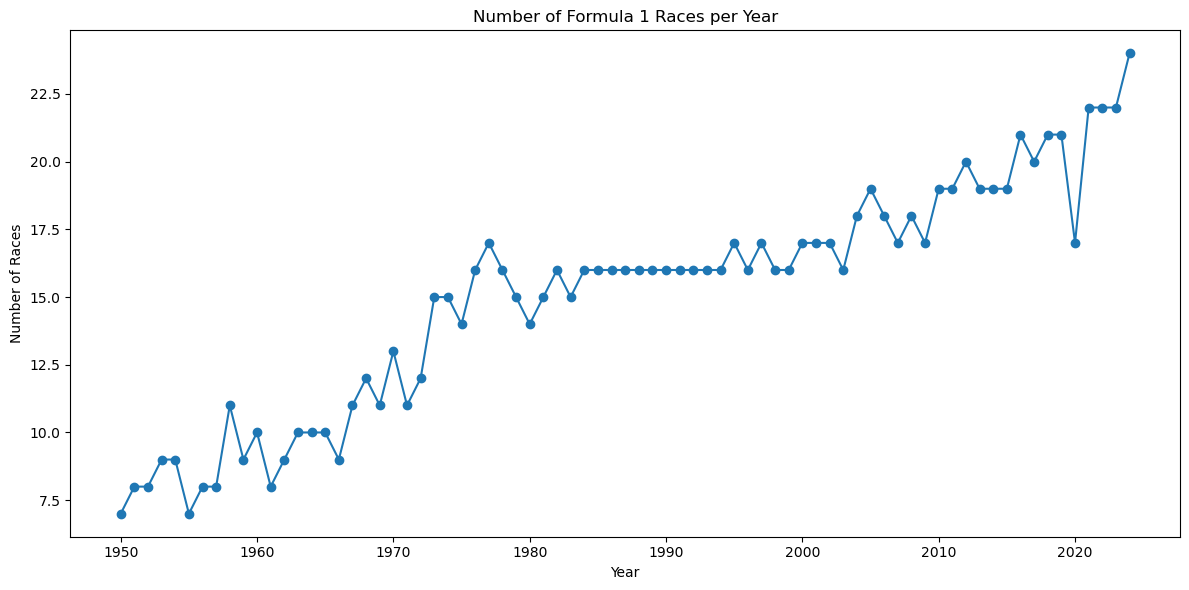

In [46]:
# Visualize the race over time
plt.figure(figsize=(12,6))

plt.plot(races_per_year.index, races_per_year.values, marker ='o')

plt.title('Number of Formula 1 Races per Year')
plt.xlabel('Year')
plt.ylabel('Number of Races')

plt.tight_layout()
plt.show()

**Note:**

The number of Formula 1 races per season has increased considerably over the period covered by the dataset.

In the early years, Formula 1 typically had fewer than 10 races per season. The number gradually increased during the 1960s and 1970s, reaching around 15–17 races per season. During the 1980s and 1990s, the number of races remained relatively stable at around 15–16 races per season.

From the 2000s onwards, the number of races increased again, reaching more than 20 races in several recent seasons. The most notable exception is **2020**, when the number of races dropped sharply. After 2020, the number of races increased again and reached the highest level in the dataset in 2024.

Overall, the data shows a long-term expansion of the Formula 1 calendar, with more races being held per season in recent years than during the early decades of the championship.

In [47]:
# How has the number of formula 1 drivers changed over time
drivers_per_year = (
    drivers_results_races_circuits_constructors_df
    .groupby('year')['driverId']
    .nunique()
)

print(drivers_per_year)

year
1950     81
1951     84
1952    105
1953    108
1954     97
       ... 
2020     23
2021     21
2022     22
2023     22
2024     24
Name: driverId, Length: 75, dtype: int64


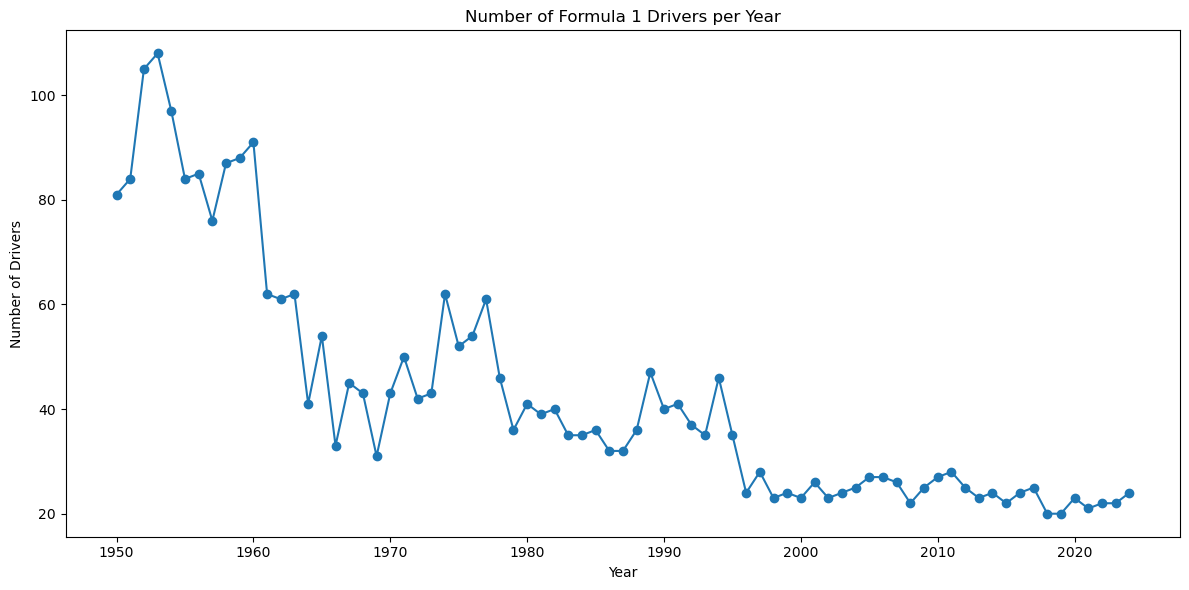

In [48]:
# Visualize the drivers over time

plt.figure(figsize=(12,6))

plt.plot(
    drivers_per_year.index,
    drivers_per_year.values,
    marker='o'
)

plt.title('Number of Formula 1 Drivers per Year')
plt.xlabel('Year')
plt.ylabel('Number of Drivers')

plt.tight_layout()
plt.show()

**Note:**

The number of unique Formula 1 drivers participating in each season has changed considerably over time.

During the early years of the championship, the number of participating drivers was very high, reaching more than **100 drivers in some seasons**. From the 1960s onwards, the number gradually decreased, although several periods show considerable fluctuations.

Since the late 1990s, the number of unique drivers per season has been much more stable, generally remaining between **20 and 30 drivers**.

When compared with the previous analysis of races per year, an interesting trend becomes visible: while the number of races per season has increased over time, the number of unique drivers participating in a season has generally decreased and become more stable.

This suggests that the modern Formula 1 grid has become more consistent, with fewer drivers participating in individual seasons compared with the early years of the championship.

In [49]:
# How many unique drivers paricipated per race on average each year
driver_races_per_year = pd.DataFrame({
    'races': races_per_year,
    'drivers': drivers_per_year
})

In [51]:
driver_races_per_year['drivers_per_year'] = (
    driver_races_per_year['drivers'] /
    driver_races_per_year['races']
)
print(driver_races_per_year.head())

      races  drivers  drivers_per_year
year                                  
1950      7       81         11.571429
1951      8       84         10.500000
1952      8      105         13.125000
1953      9      108         12.000000
1954      9       97         10.777778
